In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import tempfile

results_dir = os.path.join(tempfile.gettempdir(), "results")
os.makedirs(results_dir, exist_ok=True)

In [70]:
df = pd.read_csv("/Users/umeshkapil/Downloads/ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [71]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(2000, 17)

Column Names:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='str')

Data Types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
auto

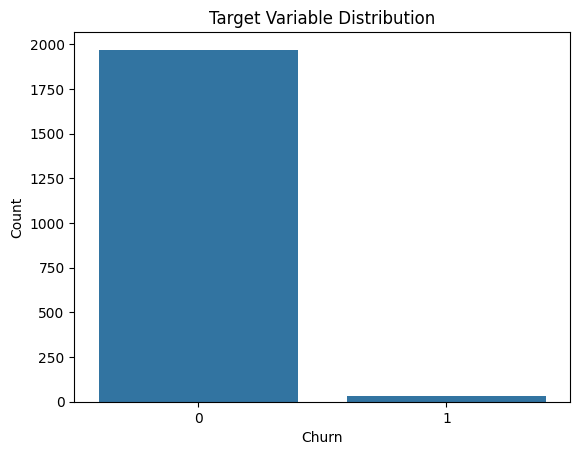

In [72]:
sns.countplot(x="churn", data=df)

plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.savefig(os.path.join(results_dir, "target_distribution.png"))

plt.show()

In [73]:
df = df.drop("customer_id", axis=1)

categorical_columns = [
    "region",
    "plan_type",
    "contract_type",
    "payment_method"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df.head()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


In [74]:
X = df.drop("churn", axis=1)

y = df["churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1600, 24)
Testing Shape: (400, 24)


In [76]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9797 - loss: 0.1857 - val_accuracy: 0.9937 - val_loss: 0.0586
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - accuracy: 0.9820 - loss: 0.0928 - val_accuracy: 0.9937 - val_loss: 0.0431
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.9820 - loss: 0.0826 - val_accuracy: 0.9937 - val_loss: 0.0410
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.9820 - loss: 0.0755 - val_accuracy: 0.9937 - val_loss: 0.0402
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0703 - val_accuracy: 0.9937 - val_loss: 0.0386
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.9820 - loss: 0.0650 - val_accuracy: 0.9937 - val_loss: 0.0378
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.9820 - loss: 0.0609 - val_accuracy: 0.9937 - val_loss: 0.0376
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.9820 - loss: 0.0576 - val_accuracy: 0.9937

In [78]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.9875 - loss: 0.0789
Test Loss: 0.07893045246601105
Test Accuracy: 0.987500011920929


In [79]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy Score:
0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



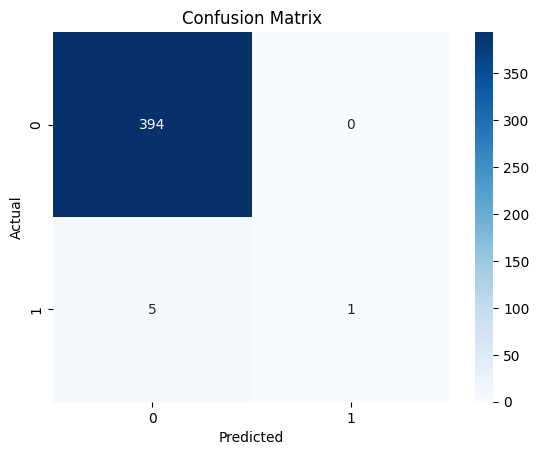

In [80]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(results_dir, "evaluation_outputs.png"))

plt.show()

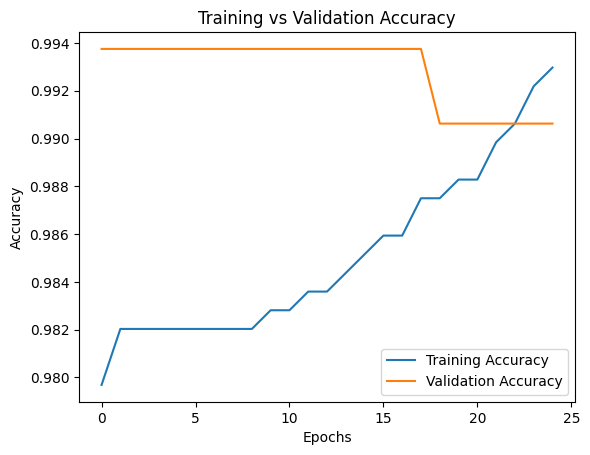

In [81]:
plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig(os.path.join(results_dir, "accuracy_graph.png"))

plt.show()

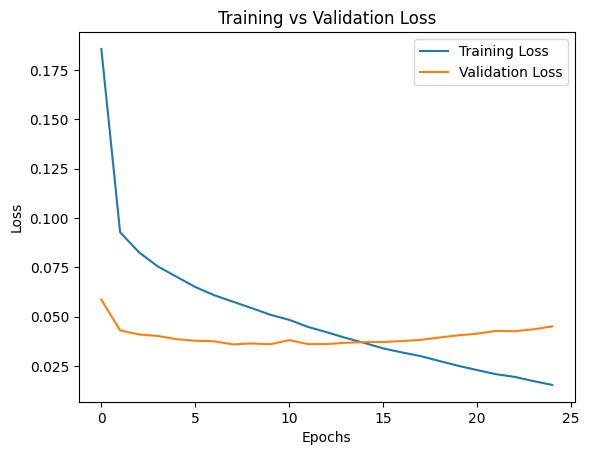

In [82]:
plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.savefig(os.path.join(results_dir, "loss_graph.png"))

plt.show()

In [83]:
results = []

def run_experiment(
    name,
    hidden_layers,
    neurons,
    learning_rate,
    batch_size,
    epochs
):

    model = Sequential()

    model.add(
        Dense(
            neurons,
            activation="relu",
            input_shape=(X_train.shape[1],)
        )
    )

    for i in range(hidden_layers - 1):
        model.add(
            Dense(
                neurons // 2,
                activation="relu"
            )
        )

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append({
        "Experiment": name,
        "Hidden Layers": hidden_layers,
        "Neurons": neurons,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Accuracy": accuracy,
        "Loss": loss
    })

run_experiment(
    "Experiment 1",
    hidden_layers=1,
    neurons=32,
    learning_rate=0.001,
    batch_size=32,
    epochs=15
)

run_experiment(
    "Experiment 2",
    hidden_layers=2,
    neurons=64,
    learning_rate=0.001,
    batch_size=32,
    epochs=25
)

run_experiment(
    "Experiment 3",
    hidden_layers=3,
    neurons=128,
    learning_rate=0.0005,
    batch_size=16,
    epochs=30
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
comparison_df = pd.DataFrame(results)

comparison_df

,Experiment,Hidden Layers,Neurons,Learning Rate,Batch Size,Epochs,Accuracy,Loss
0,Experiment 1,1,32,0.0010,32,15,0.9850,0.063772
1,Experiment 2,2,64,0.0010,32,25,0.9875,0.066634
2,Experiment 3,3,128,0.0005,16,30,0.9875,0.167717


In [85]:
comparison_df.to_csv(
    os.path.join(results_dir, "model_comparison.csv"),
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.
